# Import Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import pickle

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [2]:
RANDOM_STATE = 42

# Data Processing

## 22. Statlog Heart Disease

In [3]:
df_statlog: pd.DataFrame = pd.read_csv('data/raw/22-statlog.csv')
df_statlog.head()

,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


In [4]:
df_statlog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   270 non-null    float64
 1   sex                   270 non-null    float64
 2   chest-pain            270 non-null    float64
 3   rest-bp               270 non-null    float64
 4   serum-chol            270 non-null    float64
 5   fasting-blood-sugar   270 non-null    float64
 6   electrocardiographic  270 non-null    float64
 7   max-heart-rate        270 non-null    float64
 8   angina                270 non-null    float64
 9   oldpeak               270 non-null    float64
 10  slope                 270 non-null    float64
 11  major-vessels         270 non-null    float64
 12  thal                  270 non-null    float64
 13  heart-disease         270 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 29.7 KB


In [5]:
df_statlog.isnull().sum()

age                     0
sex                     0
chest-pain              0
rest-bp                 0
serum-chol              0
fasting-blood-sugar     0
electrocardiographic    0
max-heart-rate          0
angina                  0
oldpeak                 0
slope                   0
major-vessels           0
thal                    0
heart-disease           0
dtype: int64

In [6]:
def preprocess_statlog(df: pd.DataFrame) -> tuple:
    df_new = df.copy()
    
    # Step 1: Rename columns
    df_new.rename(columns={
        "chest-pain": "cp_type",
        "rest-bp": "sbp",
        "serum-chol": "chol",
        "fasting-blood-sugar": "fbs",
        "electrocardiographic": "ecg",
        'max-heart-rate': 'hr',
        "major-vessels": "mv",
        "heart-disease": "target"
    }, inplace=True)
    
    # Step 2: Cast to int
    for col in ["age", "sex", "cp_type", "sbp", "chol", "fbs", "ecg", "hr", "angina", "slope", "mv", "thal", "target"]:
        df_new[col] = df_new[col].astype(int)
    
    # Step 3: Map values
    df_new['thal'] = df_new['thal'].map({3: 0, 6: 1, 7: 2})
    df_new['target'] = df_new['target'].map({1: 0, 2: 1})
    
    # Step 4: Drop duplicates
    df_new.drop_duplicates(inplace=True)
    
    # Step 5: Scale continuous features to [0, 1]
    cont_cols = ['age', 'sbp', 'chol', 'hr', 'oldpeak']
    scaler = MinMaxScaler()
    df_new[cont_cols] = scaler.fit_transform(df_new[cont_cols])
    
    return df_new, scaler

In [7]:
df_preprocessed_statlog, scaler_statlog = preprocess_statlog(df_statlog)
df_preprocessed_statlog.head()

,age,sex,cp_type,sbp,chol,fbs,ecg,hr,angina,oldpeak,slope,mv,thal,target
0,0.854167,1,4,0.339623,0.447489,0,2,0.290076,0,0.387097,2,3,0,1
1,0.791667,0,3,0.198113,1.000000,0,2,0.679389,0,0.258065,2,0,2,0
2,0.583333,1,2,0.283019,0.308219,0,0,0.534351,0,0.048387,1,0,2,1
3,0.729167,1,4,0.320755,0.312785,0,0,0.259542,1,0.032258,2,1,2,0
4,0.937500,0,2,0.245283,0.326484,0,2,0.381679,1,0.032258,1,1,0,0


<b>Statlog Column Definition</b>
1. age (Numeric, scaled)      - Patient Age [0, 1]
2. sex (Categorical)          - Patient Sex
    - 0 - female
    - 1 - male
3. cp_type (Categorical)      - Chest Pain Type
    - 1 - typical angina
    - 2 - atypical angina
    - 3 - nonanginal
    - 4 - asymptomatic
4. sbp (Numeric, scaled)      - Systolic Blood Pressure [0, 1]
5. chol (Numeric, scaled)     - Cholesterol [0, 1]
6. fbs (Categorical)          - Fasting Blood Sugar > 120 mg/dL
    - 0 - false
    - 1 - true
7. ecg (Categorical)          - Resting Electrocardiographic Result
    - 0 - normal
    - 1 - ST-T wave abnormality
    - 2 - left ventricular hypertrophy
8. hr (Numeric, scaled)       - Heart Rate [0, 1]
9. angina (Categorical)       - Exercise Induced Angina
    - 0 - no
    - 1 - yes
10. oldpeak (Numeric, scaled) - ST Depression [0, 1]
11. slope (Categorical)       - Slope of peak exercise ST segment
    - 1 - upsloping
    - 2 - flat
    - 3 - downsloping
12. mv (Numeric)              - Number of Major Vessels
13. thal (Categorical)        - Defect type
    - 0 - normal
    - 1 - fixed defect
    - 2 - reversible defect
14. target (Categorical)      - Disease Status
    - 0 - No Disease
    - 1 - Have Disease

In [8]:
df_preprocessed_statlog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      270 non-null    float64
 1   sex      270 non-null    int32  
 2   cp_type  270 non-null    int32  
 3   sbp      270 non-null    float64
 4   chol     270 non-null    float64
 5   fbs      270 non-null    int32  
 6   ecg      270 non-null    int32  
 7   hr       270 non-null    float64
 8   angina   270 non-null    int32  
 9   oldpeak  270 non-null    float64
 10  slope    270 non-null    int32  
 11  mv       270 non-null    int32  
 12  thal     270 non-null    int64  
 13  target   270 non-null    int64  
dtypes: float64(5), int32(7), int64(2)
memory usage: 22.3 KB


In [9]:
statlog_categorical_cols = ["sex", "cp_type", "fbs", "ecg", "angina", "slope", "thal", "target"]
statlog_numerical_cols = df_preprocessed_statlog.columns.difference(statlog_categorical_cols)

In [10]:
def plot_categorical_distributions(df: pd.DataFrame, categorical_cols: list):
    for col in categorical_cols:
        plt.figure(figsize=(3, 5)) 
        sns.countplot(x=col, data=df)
        plt.title(f'Distribution of {col} in {df.attrs.get("dataset_name", "Unknown")} Dataset')
        plt.tight_layout()
        plt.show()
        
def plot_numerical_heatmap(df: pd.DataFrame, numerical_cols: list):
    sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
    plt.title(f'Correlation Heatmap of Numerical Features in {df.attrs.get("dataset_name", "Unknown")} Dataset')
    plt.show()

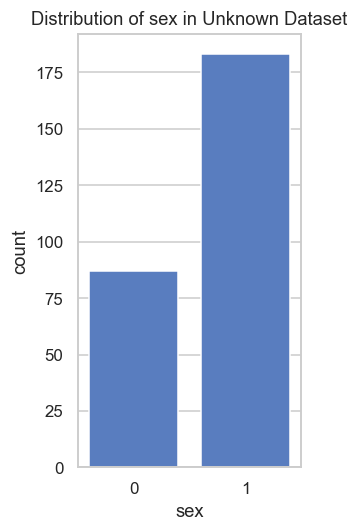

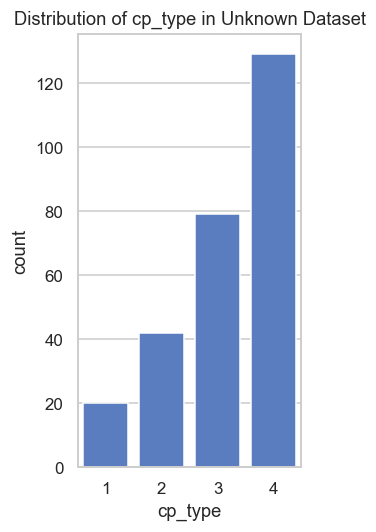

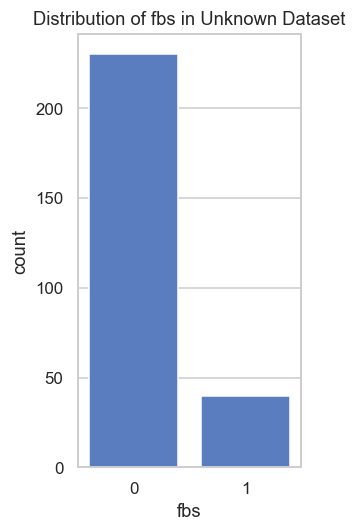

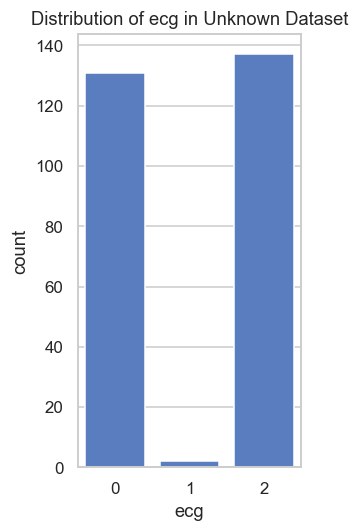

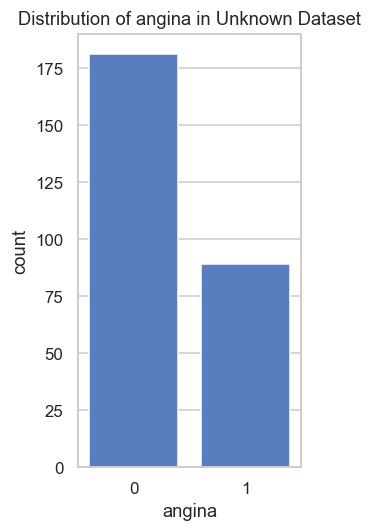

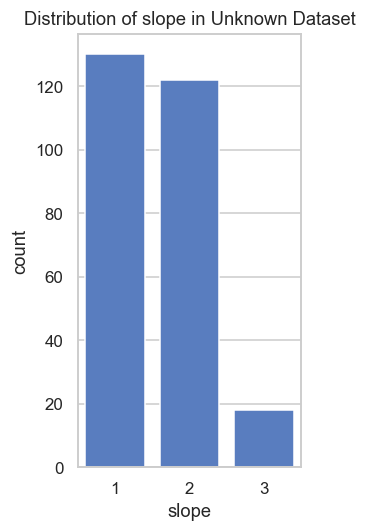

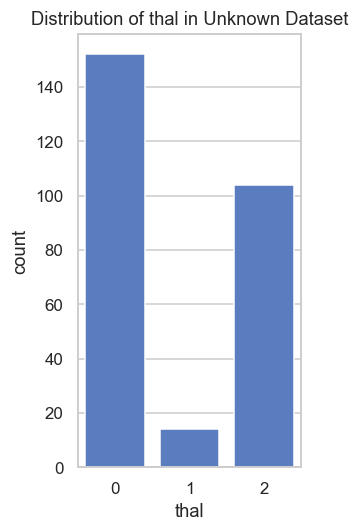

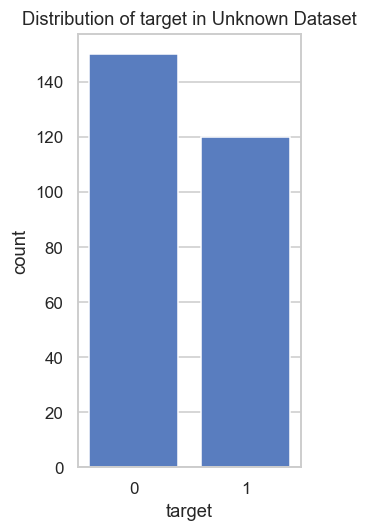

In [11]:
plot_categorical_distributions(df_preprocessed_statlog, statlog_categorical_cols)

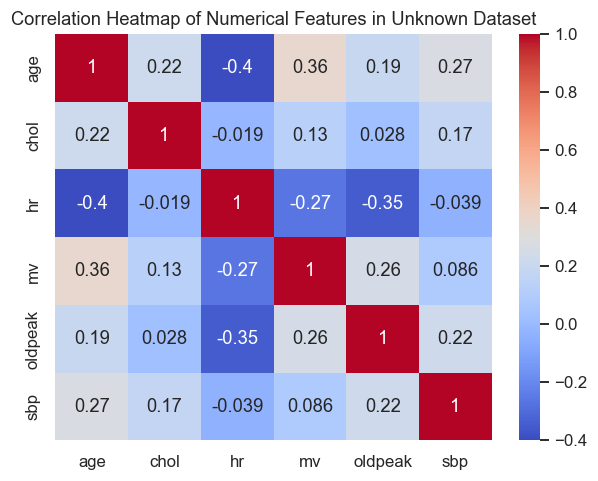

In [12]:
plot_numerical_heatmap(df_preprocessed_statlog, statlog_numerical_cols)

In [13]:
def set_preprocessed(df: pd.DataFrame, dataset_name: str, scaler: MinMaxScaler, scaler_name: str) -> pd.DataFrame:
    df.to_csv(f'data/preprocessed/{dataset_name}.csv', index=False)
    scaler_file = f'scaler/{scaler_name}.pkl'
    with open(scaler_file, 'wb') as f:
        pickle.dump(scaler, f)
    
def get_preprocessed(dataset_name: str, scaler_name: str) -> tuple:
    df = pd.read_csv(f'data/preprocessed/{dataset_name}.csv')
    with open(f'scaler/{scaler_name}.pkl', 'rb') as f:
        scaler = pickle.load(f)
    return df, scaler

In [14]:
set_preprocessed(df_preprocessed_statlog, '22-statlog-preprocessed', scaler_statlog, '22-scaler_statlog')

## 23. Coronary Heart Disease

In [15]:
df_chd = pd.read_csv('data/raw/23-chd.csv')
df_chd.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


In [16]:
df_chd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 36.2+ KB


In [17]:
df_chd.isnull().sum()

sbp          0
tobacco      0
ldl          0
adiposity    0
famhist      0
typea        0
obesity      0
alcohol      0
age          0
chd          0
dtype: int64

In [18]:
def preprocess_chd(df: pd.DataFrame) -> tuple:
    df_new = df.copy()
        
    # Step 1: Map values
    df_new['famhist'] = df_new['famhist'].map({'Present': 1, 'Absent': 0})

    # Step 2: Rename columns
    df_new.rename(columns={
        'chd': 'target'
    }, inplace=True)
    
    # Step 3: Drop duplicates
    df_new.drop_duplicates(inplace=True)
    
    # Step 4: Scale continuous features to [0, 1]
    cont_cols = ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age']
    scaler = MinMaxScaler()
    df_new[cont_cols] = scaler.fit_transform(df_new[cont_cols])
    
    return df_new, scaler

In [19]:
df_preprocessed_chd, scaler_chd = preprocess_chd(df_chd)
df_preprocessed_chd.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,target
0,0.504274,0.384615,0.331010,0.457902,1,0.553846,0.332497,0.660371,0.755102,1
1,0.367521,0.000321,0.239024,0.611748,0,0.646154,0.444479,0.013996,0.979592,1
2,0.145299,0.002564,0.174216,0.714406,1,0.600000,0.452949,0.025885,0.632653,0
3,0.589744,0.240385,0.378397,0.875245,1,0.584615,0.542346,0.164821,0.877551,1
4,0.282051,0.435897,0.175610,0.588531,1,0.723077,0.354141,0.389565,0.693878,1


In [20]:
chd_categorical_cols = ["famhist", "target"]
chd_numerical_cols = df_preprocessed_chd.columns.difference(chd_categorical_cols)

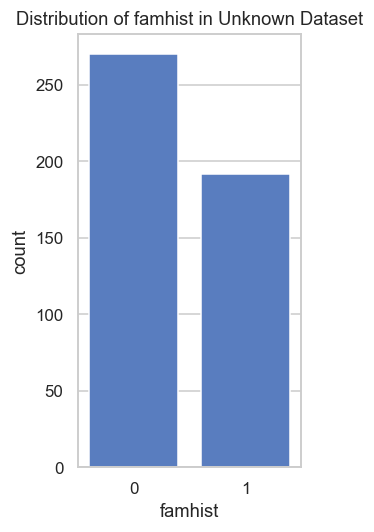

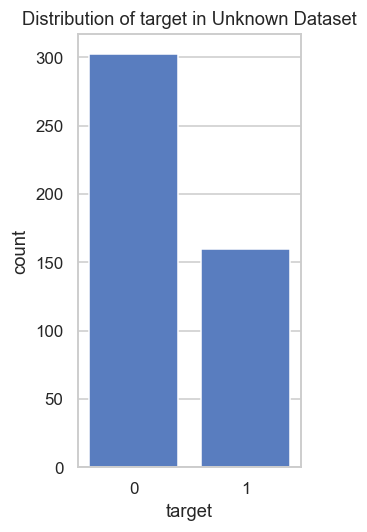

In [21]:
plot_categorical_distributions(df_preprocessed_chd, chd_categorical_cols)

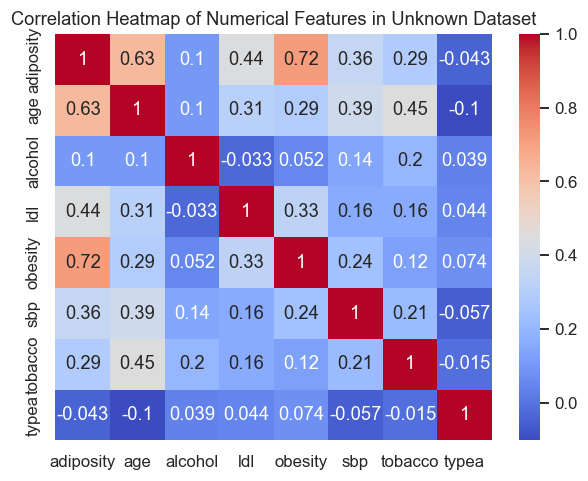

In [22]:
plot_numerical_heatmap(df_preprocessed_chd, chd_numerical_cols)

In [23]:
set_preprocessed(df_preprocessed_chd, '23-chd-preprocessed', scaler_chd, '23-chd-scaler')

## 24. Framingham

In [24]:
df_framingham = pd.read_csv('data/raw/24-framingham.csv')
df_framingham.head()

,Sex,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,male,39,4.0,No,0.0,0.0,0,0,No,195.0,106.0,70.0,26.97,80.0,77.0,0
1,female,46,2.0,No,0.0,0.0,0,0,No,250.0,121.0,81.0,28.73,95.0,76.0,0
2,male,48,1.0,Yes,20.0,0.0,0,0,No,245.0,127.5,80.0,25.34,75.0,70.0,0
3,female,61,3.0,Yes,30.0,0.0,0,1,No,225.0,150.0,95.0,28.58,65.0,103.0,1
4,female,46,3.0,Yes,23.0,0.0,0,0,No,285.0,130.0,84.0,23.10,85.0,85.0,0


## 25. Heart Disease

In [25]:
df_heart = pd.read_csv('data/raw/25-heart.csv')
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [26]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [27]:
def preprocess_heart(df: pd.DataFrame) -> pd.DataFrame:
    df_new = df.copy()
    
    # Rename columns
    df_new.rename(columns={
        "cp": "cp_type",
        "trestbps": "sbp",
        "restecg": "ecg",
        "thalach": "hr",
        "exang": "angina",
        "ca": "mv"
    }, inplace=True)
    
    # Change cp_type values: 0 -> 1 (typical angina), 1 -> 2 (atypical angina), 2 -> 3 (non-anginal pain), 3 -> 4 (asymptomatic)
    df_new['cp_type'] = df_new['cp_type'].map({0: 1, 1: 2, 2: 3, 3: 4})

    # Change slope values: 0 -> 1 (upsloping), 1 -> 2 (flat), 2 -> 3 (downsloping)
    df_new['slope'] = df_new['slope'].map({0: 1, 1: 2, 2: 3})
    
    # Drop duplicates
    df_new.drop_duplicates(inplace=True)

    return df_new

In [28]:
df_preprocessed_heart = preprocess_heart(df_heart)
df_preprocessed_heart.head()

,age,sex,cp_type,sbp,chol,fbs,ecg,hr,angina,oldpeak,slope,mv,thal,target
0,52,1,1,125,212,0,1,168,0,1.0,3,2,3,0
1,53,1,1,140,203,1,0,155,1,3.1,1,0,3,0
2,70,1,1,145,174,0,1,125,1,2.6,1,0,3,0
3,61,1,1,148,203,0,1,161,0,0.0,3,1,3,0
4,62,0,1,138,294,1,1,106,0,1.9,2,3,2,0


<b>Heart Disease Column Definition</b>
1. age (Numeric)            - Patient Age
2. sex (Categorical)        - Patient Sex
    - 0 - female
    - 1 - male
3. cp_type (Categorical)    - Chest Pain Type
    - 1 - typical angina
    - 2 - atypical angina
    - 3 - nonanginal
    - 4 - asymptomatic
4. sbp (Numeric)            - Systolic Blood Pressure
5. chol (Numeric)           - Cholesterol
6. fbs (Categorical)        - Fasting Blood Sugar > 120 mg/dL
    - 0 - false
    - 1 - true
7. ecg (Categorical)        - Resting Electrocardiographic Result
    - 0 - normal
    - 1 - ST-T wave abnormality
    - 2 - left ventricular hypertrophy
8. hr (Numeric)             - Heart Rate
9. angina (Categorical)     - Exercise Induced Angina
    - 0 - no
    - 1 - yes
10. oldpeak (Numeric)       - ST Depression induced by exercise relative to the rest
11. slope (Categorical)     - Slope of peak exercise ST segment
    - 1 - upsloping
    - 2 - flat
    - 3 - downsloping
12. mv (Numeric)            - Number of Major Vessels
13. thal (Categorical)      - Defect type
    - 0 - normal
    - 1 - fixed defect
    - 2 - reversible defect
    - 3 - unknown
14. target (Categorical)    - Absent or Present
    - 0 - Absence
    - 1 - Presence

In [29]:
df_preprocessed_heart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      302 non-null    int64  
 1   sex      302 non-null    int64  
 2   cp_type  302 non-null    int64  
 3   sbp      302 non-null    int64  
 4   chol     302 non-null    int64  
 5   fbs      302 non-null    int64  
 6   ecg      302 non-null    int64  
 7   hr       302 non-null    int64  
 8   angina   302 non-null    int64  
 9   oldpeak  302 non-null    float64
 10  slope    302 non-null    int64  
 11  mv       302 non-null    int64  
 12  thal     302 non-null    int64  
 13  target   302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


In [30]:
df_preprocessed_heart.isna().sum()

age        0
sex        0
cp_type    0
sbp        0
chol       0
fbs        0
ecg        0
hr         0
angina     0
oldpeak    0
slope      0
mv         0
thal       0
target     0
dtype: int64

In [31]:
heart_categorical_cols = ["sex", "cp_type", "fbs", "ecg", "angina", "slope", "thal", "target"]
heart_numerical_cols = df_preprocessed_heart.columns.difference(heart_categorical_cols)

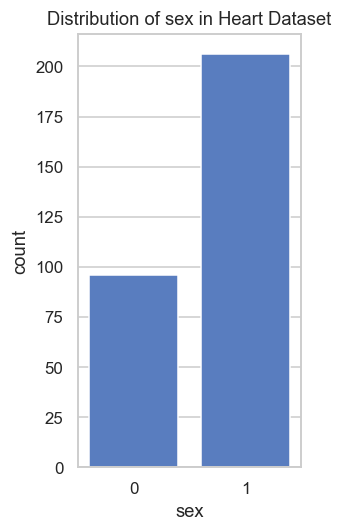

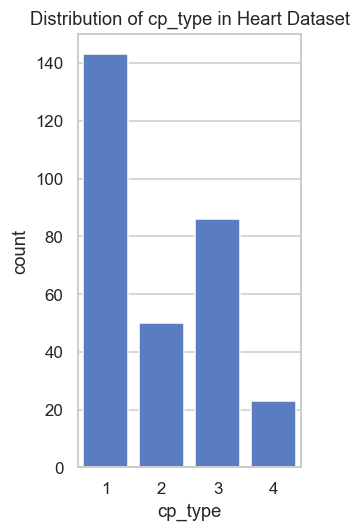

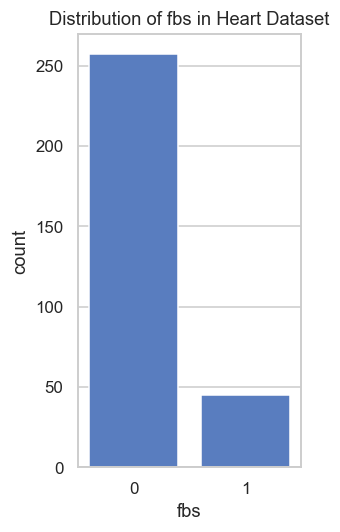

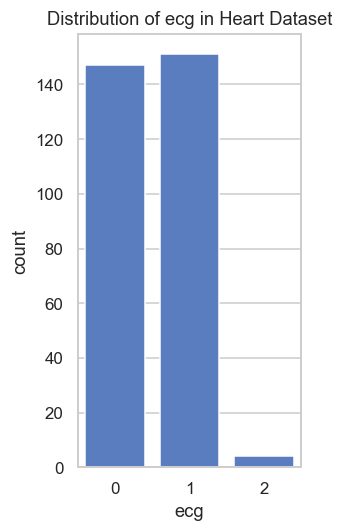

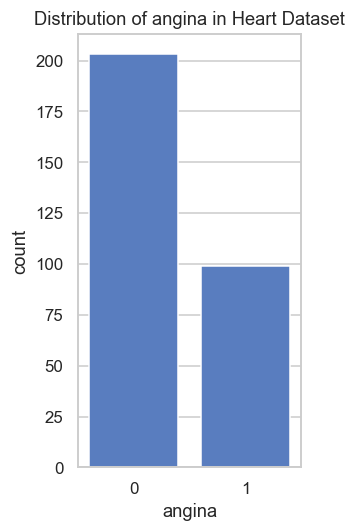

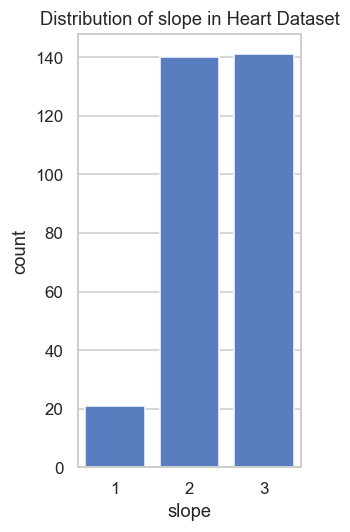

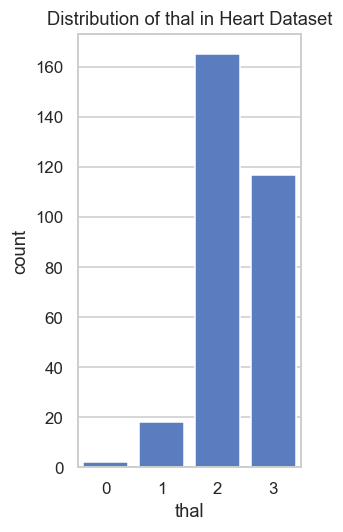

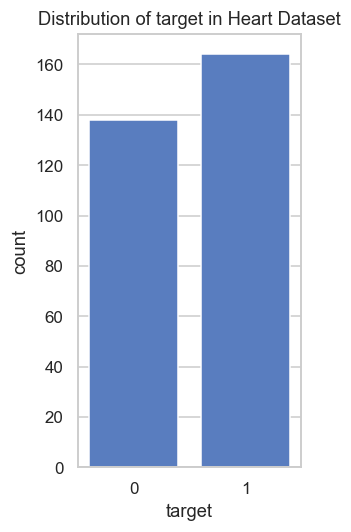

In [32]:
for col in heart_categorical_cols:
    plt.figure(figsize=(3, 5)) 
    sns.countplot(x=col, data=df_preprocessed_heart)
    plt.title(f'Distribution of {col} in Heart Dataset')
    plt.tight_layout()
    plt.show()

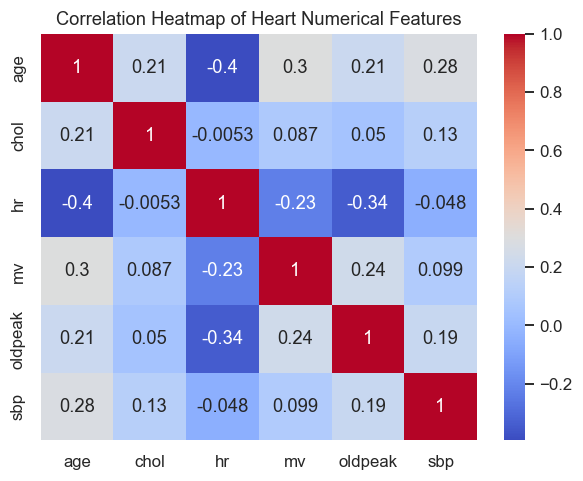

In [33]:
sns.heatmap(df_preprocessed_heart[heart_numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Heart Numerical Features')
plt.show()

## 26. Stroke

In [34]:
df_stroke = pd.read_csv('data/raw/26-stroke.csv')
df_stroke.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Concatenation

In [35]:
df_statlog_heart = pd.concat([df_preprocessed_statlog, df_preprocessed_heart], ignore_index=True)
df_statlog_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      572 non-null    float64
 1   sex      572 non-null    int64  
 2   cp_type  572 non-null    int64  
 3   sbp      572 non-null    float64
 4   chol     572 non-null    float64
 5   fbs      572 non-null    int64  
 6   ecg      572 non-null    int64  
 7   hr       572 non-null    float64
 8   angina   572 non-null    int64  
 9   oldpeak  572 non-null    float64
 10  slope    572 non-null    int64  
 11  mv       572 non-null    int64  
 12  thal     572 non-null    int64  
 13  target   572 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 62.7 KB


In [36]:
df_statlog_heart.drop_duplicates(inplace=True)
df_statlog_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      572 non-null    float64
 1   sex      572 non-null    int64  
 2   cp_type  572 non-null    int64  
 3   sbp      572 non-null    float64
 4   chol     572 non-null    float64
 5   fbs      572 non-null    int64  
 6   ecg      572 non-null    int64  
 7   hr       572 non-null    float64
 8   angina   572 non-null    int64  
 9   oldpeak  572 non-null    float64
 10  slope    572 non-null    int64  
 11  mv       572 non-null    int64  
 12  thal     572 non-null    int64  
 13  target   572 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 62.7 KB


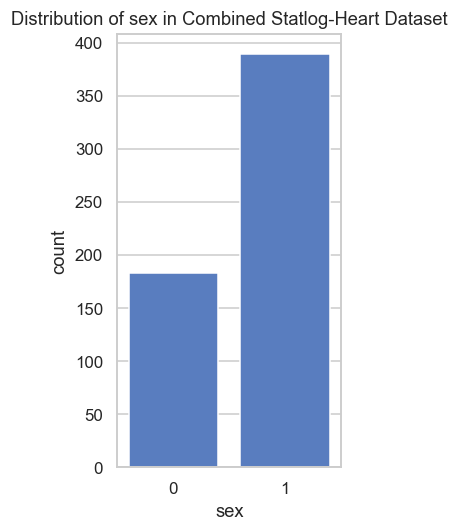

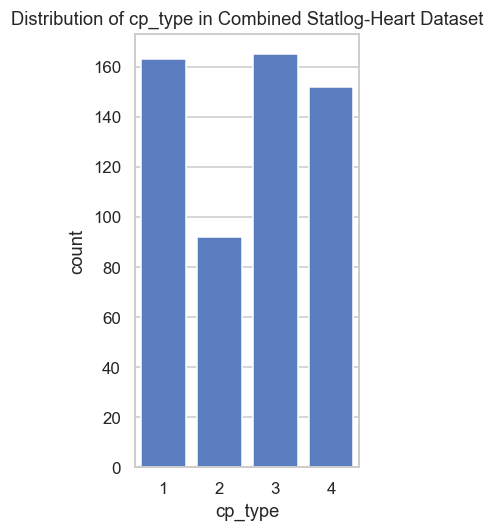

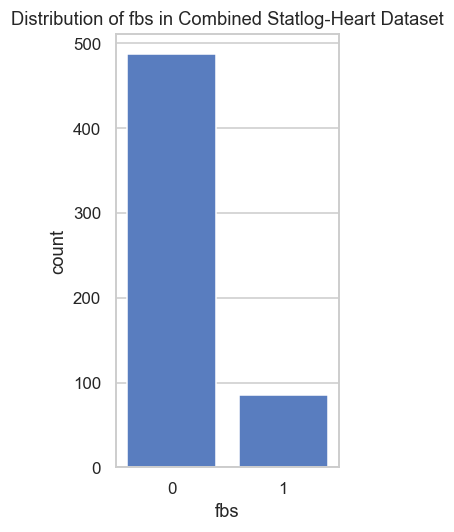

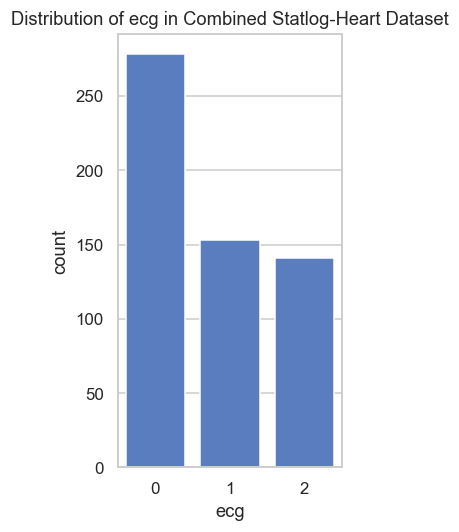

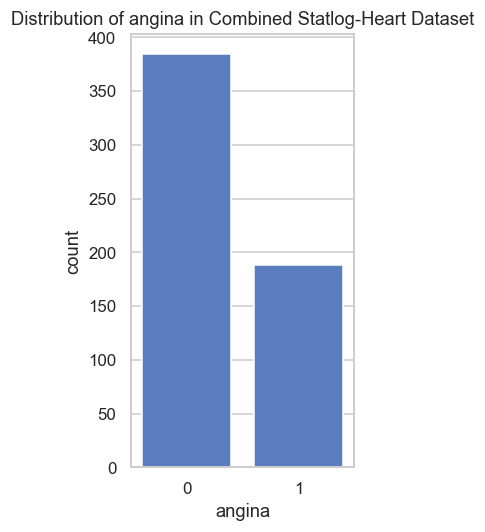

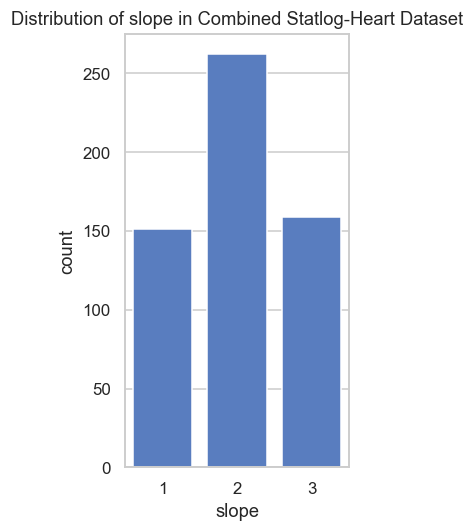

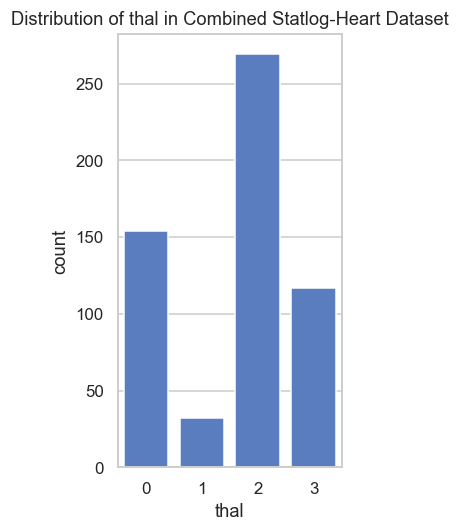

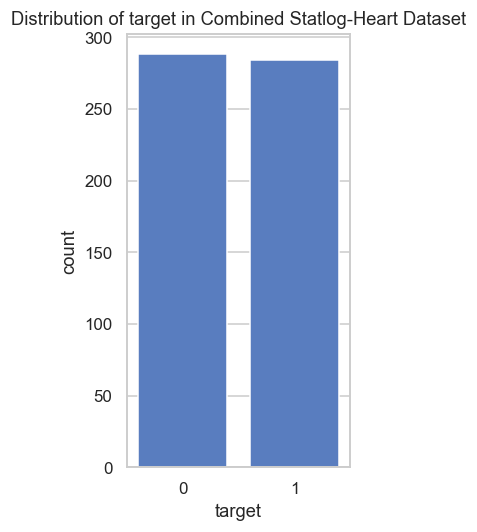

In [37]:
statlog_heart_categorical_cols = ["sex", "cp_type", "fbs", "ecg", "angina", "slope", "thal", "target"]
statlog_heart_numerical_cols = df_statlog_heart.columns.difference(statlog_heart_categorical_cols)

for col in statlog_heart_categorical_cols:
    plt.figure(figsize=(3, 5)) 
    sns.countplot(x=col, data=df_statlog_heart)
    plt.title(f'Distribution of {col} in Combined Statlog-Heart Dataset')
    plt.tight_layout()
    plt.show()

Text(0.5, 1.0, 'Correlation Heatmap of Combined Statlog-Heart Numerical Features')

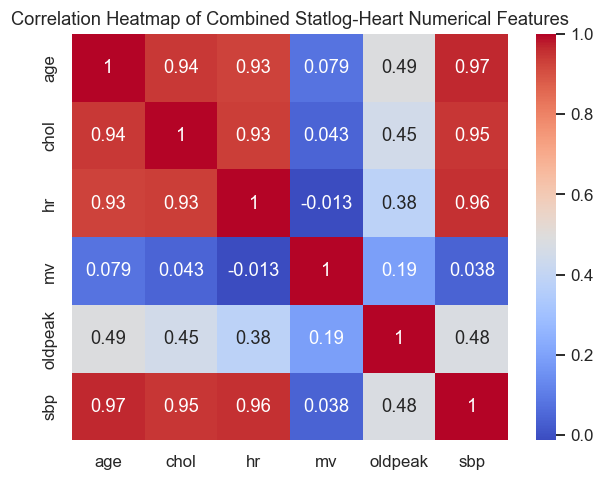

In [38]:
sns.heatmap(df_statlog_heart[statlog_heart_numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Combined Statlog-Heart Numerical Features')